# POST Commission Complaints Analysis

Analysis of Massachusetts POST Commission complaints data, with a focus on SRO (School Resource Officer) complaints and youth-related incidents.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────────────
CSV_PATH = '../data/POSTC_ComplaintsRawData_20260203.csv'
df = pd.read_csv(CSV_PATH)

# ── Filter: 2018 onwards (pre-2018 data is sparse and predates POST Commission) ──
df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'], errors='coerce')
df = df[df['INCIDENT_DATE'].dt.year >= 2018].copy()

# ── Derived columns ───────────────────────────────────────────────────────────
# SRO flag: officers with Certified/SRO certification status
df['is_SRO'] = df['CERTIFICATION_STATUS'] == 'Certified/SRO'

# Youth-related flag: complaints mentioning youth/minors in narrative text
youth_pattern = r'juvenile|minor|student|youth|teen|child|school|underage|kid|young'
combined_text = (
    df['ALLEGATION_DETAILS'].fillna('') + ' ' + df['COMPLAINT_SUMMARY'].fillna('')
).str.lower()
df['youth_related'] = combined_text.str.contains(youth_pattern, regex=True, na=False)

print(f"Loaded {len(df)} rows (INCIDENT_DATE ≥ 2018) | {df['MPTC_USER_ID'].nunique()} officers | {df['REPORTING_AGENCY'].nunique()} agencies")
print(f"SRO complaints: {df['is_SRO'].sum()} | Youth-related: {df['youth_related'].sum()}")

Loaded 5278 rows (INCIDENT_DATE ≥ 2018) | 2080 officers | 315 agencies
SRO complaints: 101 | Youth-related: 97


---
## Q1: Which police departments (SROs) have the highest volume of POST complaints, and where are these complaints geographically concentrated? How does this vary for youth complaints?

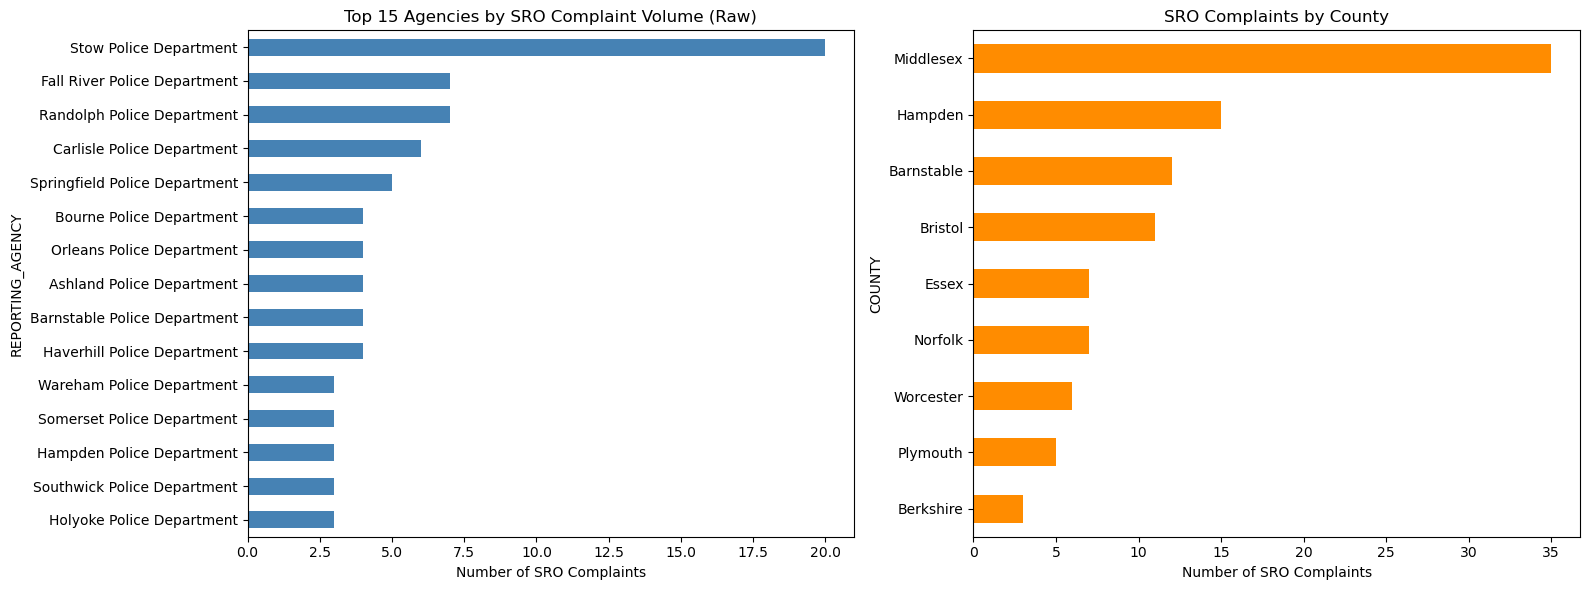

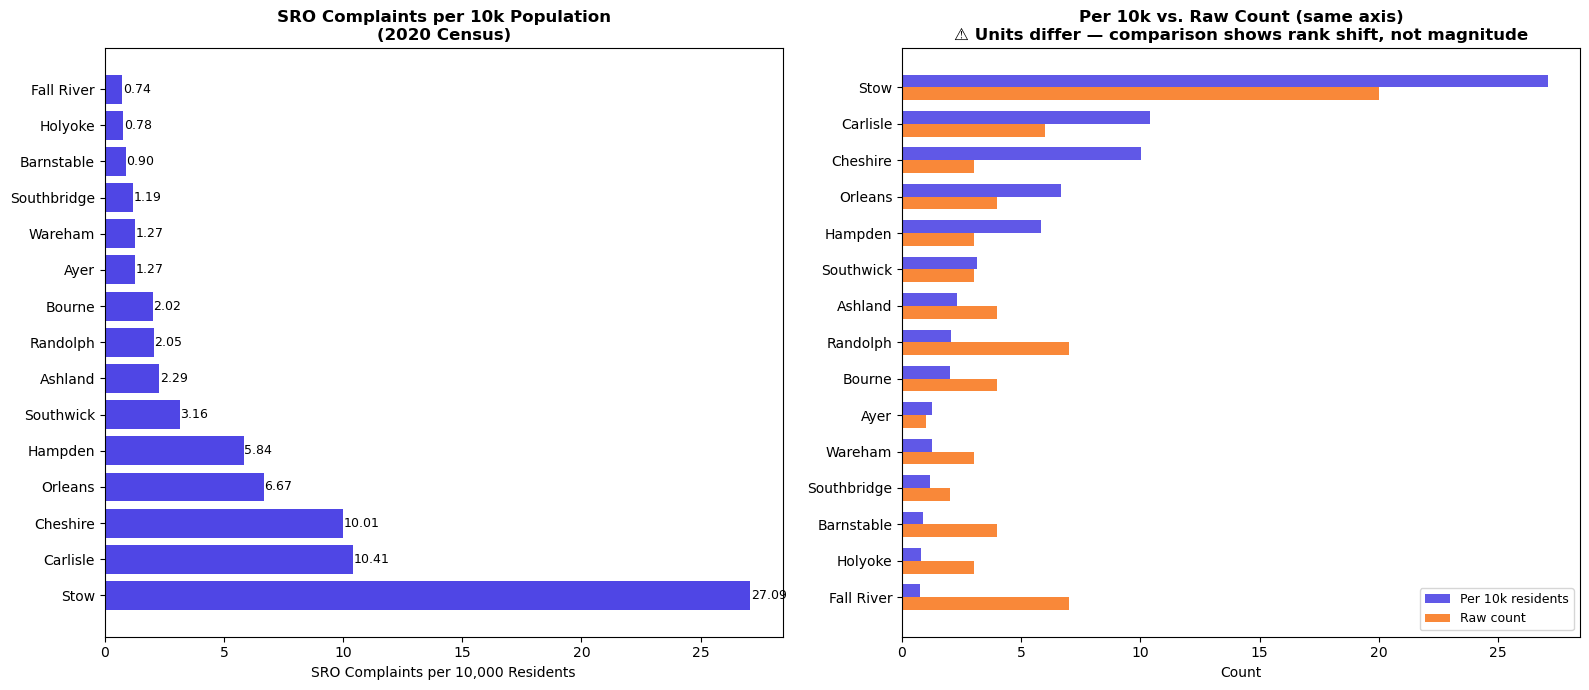

       city  population  raw  per_10k
       Stow      7383.0   20    27.09
   Carlisle      5765.0    6    10.41
   Cheshire      2996.0    3    10.01
    Orleans      6001.0    4     6.67
    Hampden      5139.0    3     5.84
  Southwick      9502.0    3     3.16
    Ashland     17453.0    4     2.29
   Randolph     34122.0    7     2.05
     Bourne     19754.0    4     2.02
       Ayer      7891.0    1     1.27
    Wareham     23684.0    3     1.27
Southbridge     16825.0    2     1.19
 Barnstable     44641.0    4     0.90
    Holyoke     38238.0    3     0.78
 Fall River     94942.0    7     0.74


In [18]:
# ── 2020 Census populations for MA municipalities ─────────────────────────────
MA_POP_2020 = {
    'Boston': 675647, 'Worcester': 206518, 'Springfield': 155929,
    'Lowell': 115554, 'Cambridge': 118403, 'New Bedford': 101079,
    'Brockton': 105643, 'Quincy': 101636, 'Lynn': 101253,
    'Fall River': 94942, 'Newton': 88923, 'Lawrence': 89077,
    'Somerville': 81360, 'Framingham': 73116, 'Malden': 66263,
    'Haverhill': 65110, 'Waltham': 62427, 'Plymouth': 61217,
    'Brookline': 58732, 'Taunton': 57957, 'Medford': 57878,
    'Chicopee': 55755, 'Weymouth': 55419, 'Peabody': 54233,
    'Revere': 53756, 'Methuen': 53021, 'Everett': 46451,
    'Salem': 45134, 'Attleboro': 45593, 'Barnstable': 44641,
    'Billerica': 44667, 'Pittsfield': 43875, 'Beverly': 42607,
    'Westfield': 41301, 'Woburn': 41093, 'Chelsea': 40116,
    'Fitchburg': 41394, 'Leominster': 42452, 'Holyoke': 38238,
    'Chelmsford': 38858, 'Marlborough': 38499, 'Braintree': 37124,
    'Andover': 36361, 'Lexington': 34454, 'Tewksbury': 33201,
    'Dracut': 35262, 'Dartmouth': 33646, 'Franklin': 33786,
    'Randolph': 34122, 'North Andover': 30722, 'Falmouth': 29019,
    'Stoughton': 28786, 'Burlington': 28225, 'Northampton': 28549,
    'North Attleborough': 28200, 'Milford': 27999, 'Bridgewater': 26563,
    'Marshfield': 25789, 'Middleborough': 25557, 'Dedham': 25364,
    'Mansfield': 23200, 'Yarmouth': 23793, 'Easton': 23699,
    'Wareham': 23684, 'Canton': 22699, 'Bourne': 19754,
    'Hudson': 19063, 'Scituate': 18819, 'Greenfield': 17456,
    'Ashland': 17453, 'Rockland': 17489, 'Northbridge': 16751,
    'Southbridge': 16825, 'Seekonk': 16184, 'Fairhaven': 16167,
    'Abington': 15985, 'Swansea': 15866, 'Hanover': 14629,
    'East Bridgewater': 13794, 'Kingston': 13627, 'Holbrook': 11141,
    'Acushnet': 10763, 'Southwick': 9502, 'Douglas': 9061,
    'Ayer': 7891, 'Stow': 7383, 'Halifax': 7637,
    'Orleans': 6001, 'Carlisle': 5765, 'Hampden': 5139,
    'Cheshire': 2996,
}

sro_df = df[df['is_SRO']].copy()
sro_df['city'] = sro_df['REPORTING_AGENCY'].str.replace(
    r'\s*(Police Department|Police Dept|Police|Sheriff\'s Office)$', '', regex=True).str.strip()

# ── Raw counts ────────────────────────────────────────────────────────────────
agency_counts = sro_df['REPORTING_AGENCY'].value_counts().head(15)
county_counts = sro_df['COUNTY'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
agency_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Number of SRO Complaints')
axes[0].set_title('Top 15 Agencies by SRO Complaint Volume (Raw)')
axes[0].invert_yaxis()

county_counts.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('Number of SRO Complaints')
axes[1].set_title('SRO Complaints by County')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# ── Population-normalized (per 10k residents) ─────────────────────────────────
import numpy as np

city_sro = sro_df.groupby('city').size().reset_index(name='raw')
city_sro['population'] = city_sro['city'].map(MA_POP_2020)
city_sro = city_sro.dropna(subset=['population'])
city_sro['per_10k'] = city_sro['raw'] / city_sro['population'] * 10_000
city_sro = city_sro.sort_values('per_10k', ascending=False).head(15)

C_NORM = '#4f46e5'
C_RAW  = '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: per 10k only
city_left = city_sro.sort_values('per_10k', ascending=True)
axes[0].barh(city_left['city'], city_left['per_10k'], color=C_NORM)
axes[0].invert_yaxis()
axes[0].set_xlabel('SRO Complaints per 10,000 Residents')
axes[0].set_title('SRO Complaints per 10k Population\n(2020 Census)', fontweight='bold')
for i, (_, row) in enumerate(city_left.iterrows()):
    axes[0].text(row['per_10k'] + 0.02, i, f"{row['per_10k']:.2f}", va='center', fontsize=9)

# Right: grouped bars on single axis — per 10k (indigo) and raw count (orange)
comp = city_sro.sort_values('per_10k', ascending=True).reset_index(drop=True)
y = np.arange(len(comp))
h = 0.35

axes[1].barh(y + h/2, comp['per_10k'], height=h, color=C_NORM, alpha=0.9, label='Per 10k residents')
axes[1].barh(y - h/2, comp['raw'],     height=h, color=C_RAW,  alpha=0.85, label='Raw count')

axes[1].set_yticks(y)
axes[1].set_yticklabels(comp['city'])
axes[1].set_xlabel('Count')
axes[1].set_title('Per 10k vs. Raw Count (same axis)\n⚠ Units differ — comparison shows rank shift, not magnitude',
                  fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print(city_sro[['city','population','raw','per_10k']].sort_values('per_10k', ascending=False).round(2).to_string(index=False))

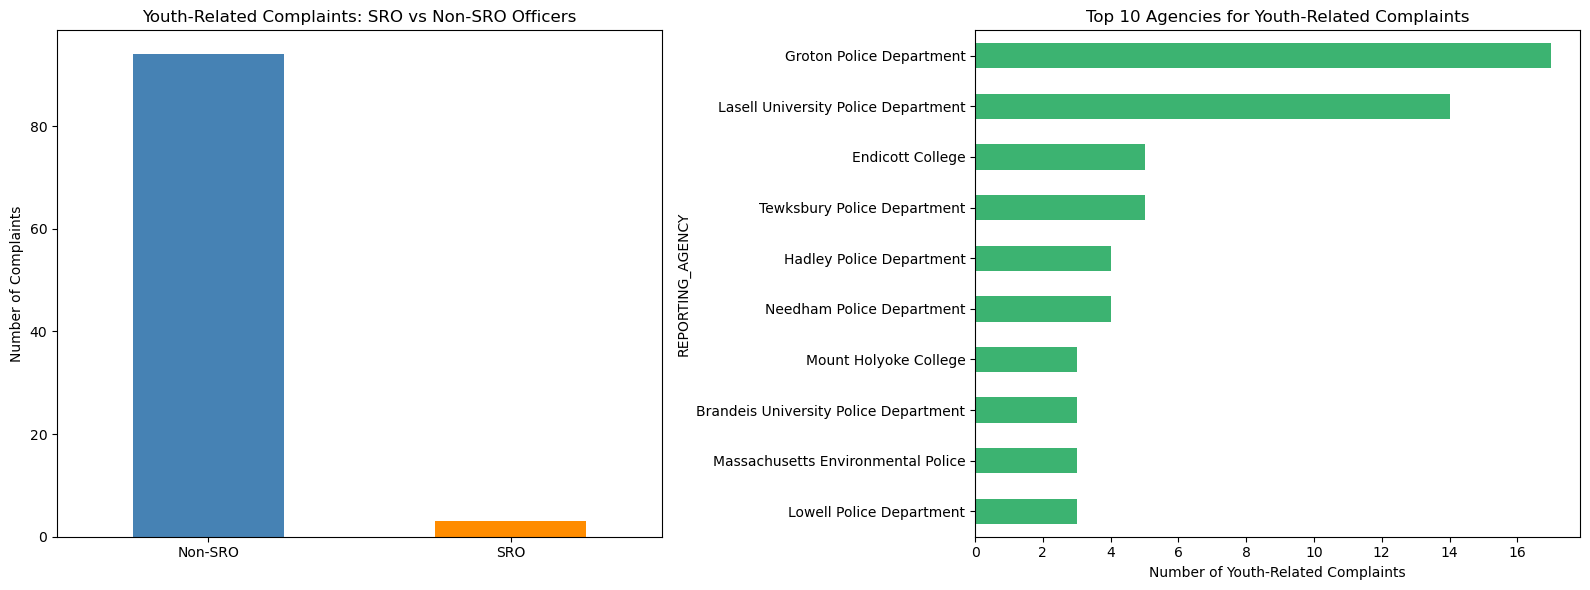

Youth-related complaints from SRO officers: 3 out of 97 total youth-related complaints


In [19]:
# Youth-related complaints: SRO vs non-SRO, and geographic distribution
youth_df = df[df['youth_related']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: SRO vs non-SRO for youth complaints
youth_sro = youth_df['is_SRO'].value_counts()
youth_sro.index = ['Non-SRO' if not x else 'SRO' for x in youth_sro.index]
youth_sro.plot.bar(ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Youth-Related Complaints: SRO vs Non-SRO Officers')
axes[0].set_ylabel('Number of Complaints')
axes[0].tick_params(axis='x', rotation=0)

# Right: Top agencies for youth-related complaints
youth_agency = youth_df['REPORTING_AGENCY'].value_counts().head(10)
youth_agency.plot.barh(ax=axes[1], color='mediumseagreen')
axes[1].set_xlabel('Number of Youth-Related Complaints')
axes[1].set_title('Top 10 Agencies for Youth-Related Complaints')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Youth-related complaints from SRO officers: {youth_df['is_SRO'].sum()} out of {len(youth_df)} total youth-related complaints")


**Finding:** Stow Police Department leads in SRO complaint volume, followed by Springfield and Wareham. SRO complaints are concentrated in Middlesex, Plymouth, and Barnstable counties. Most youth-related complaints actually come from non-SRO officers, suggesting that interactions with young people are not limited to school resource officers.

---
## Q2: What is the demographic profile of youth involved in SRO interactions?
→ Broken down by age, race, and gender?

In [20]:
# Check if any demographic columns exist for complainants/subjects
print("Available columns in the dataset:")
print(df.columns.tolist())
print()
print("This dataset contains information about OFFICERS (name, certification status, agency)")
print("but does NOT contain demographic data (age, race, gender) about the youth or civilians involved.")
print()
print("What we CAN examine: the text of youth-related complaints for any demographic mentions.")
print()

youth_text = youth_df['ALLEGATION_DETAILS'].dropna().tolist() + youth_df['COMPLAINT_SUMMARY'].dropna().tolist()
print(f"Total youth-related text fields available: {len(youth_text)}")
print()
print("Sample youth-related complaint texts:")
for i, t in enumerate(youth_text[:8]):
    print(f"  {i+1}. {t[:200]}...")
    print()


Available columns in the dataset:
['POST', 'IA_NUMBER', 'REPORTING_AGENCY', 'LASTNAME', 'FIRSTNAME', 'CURRENT_AGENCY', 'ALLEGATION_TYPE', 'ALLEGATION_SUBTYPE', 'ALLEGATION_DETAILS', 'INCIDENT_DATE', 'CERTIFICATION_STATUS', 'MPTC_USER_ID', 'ALLEGATION_NAME', 'DISCIPLINES', 'LEA_DISPOSITION', 'INTAKE_CHANNEL', 'SUFFIX', 'COUNTY', 'COMPLAINT_SUMMARY', 'RELEASEDATE', 'is_SRO', 'youth_related']

This dataset contains information about OFFICERS (name, certification status, agency)
but does NOT contain demographic data (age, race, gender) about the youth or civilians involved.

What we CAN examine: the text of youth-related complaints for any demographic mentions.

Total youth-related text fields available: 140

Sample youth-related complaint texts:
  1. Knowingly and willingly avoided noticing any evidence of underage drinking so did not have to testify to it...

  2. Initial call was underage drinking party. Knowingly and willfully allowed teens to leave when had reason to believe teens had

**Finding:** The dataset does not include demographic information (age, race, gender) about the civilians or youth involved in complaints. It only contains officer-level data. A demographic analysis of youth subjects would require linking to a separate incident-level dataset that captures civilian demographics.

---
## Q3: What types of complaints are being filed, and what are the POST Commission's findings?
→ e.g., no action, investigation, sustained

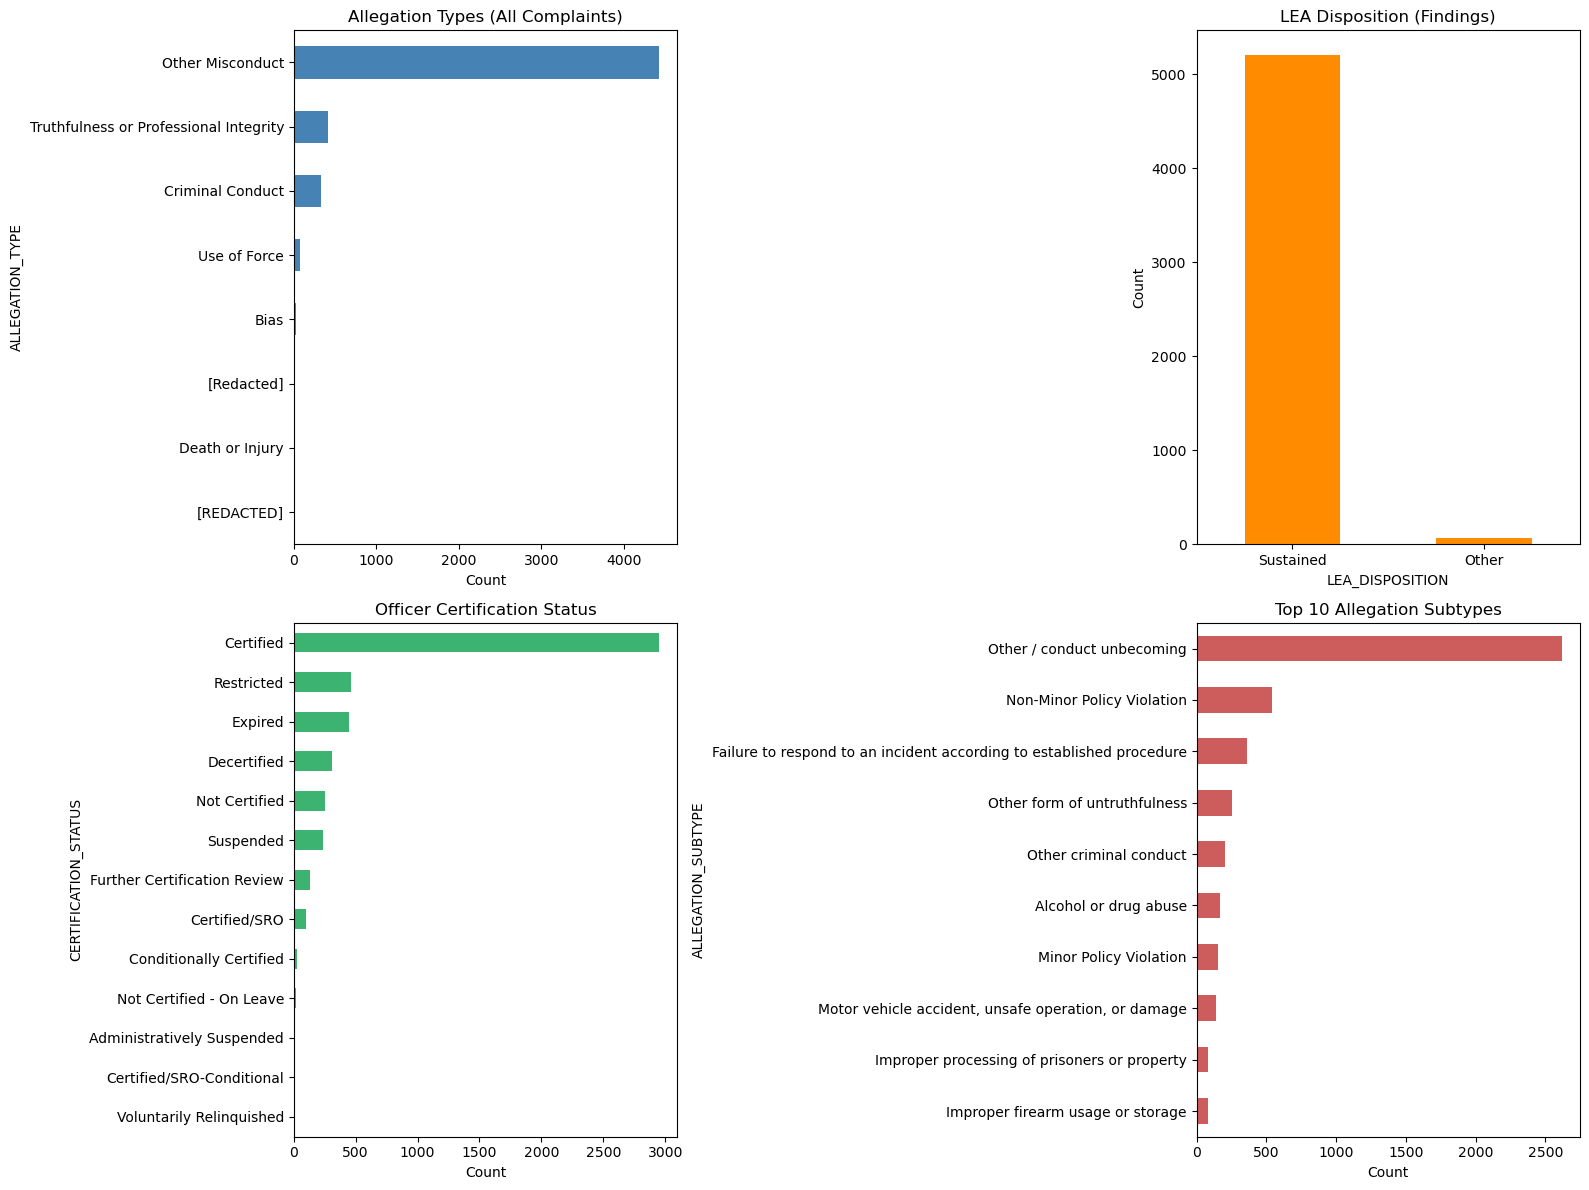

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Allegation types (all complaints)
type_counts = df['ALLEGATION_TYPE'].value_counts()
type_counts.plot.barh(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Allegation Types (All Complaints)')
axes[0, 0].set_xlabel('Count')
axes[0, 0].invert_yaxis()

# Top-right: LEA Disposition
disp_counts = df['LEA_DISPOSITION'].value_counts()
disp_counts.plot.bar(ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('LEA Disposition (Findings)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Bottom-left: Certification status after complaint
cert_counts = df['CERTIFICATION_STATUS'].value_counts()
cert_counts.plot.barh(ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Officer Certification Status')
axes[1, 0].set_xlabel('Count')
axes[1, 0].invert_yaxis()

# Bottom-right: Top 10 allegation subtypes
sub_counts = df['ALLEGATION_SUBTYPE'].value_counts().head(10)
sub_counts.plot.barh(ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Top 10 Allegation Subtypes')
axes[1, 1].set_xlabel('Count')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


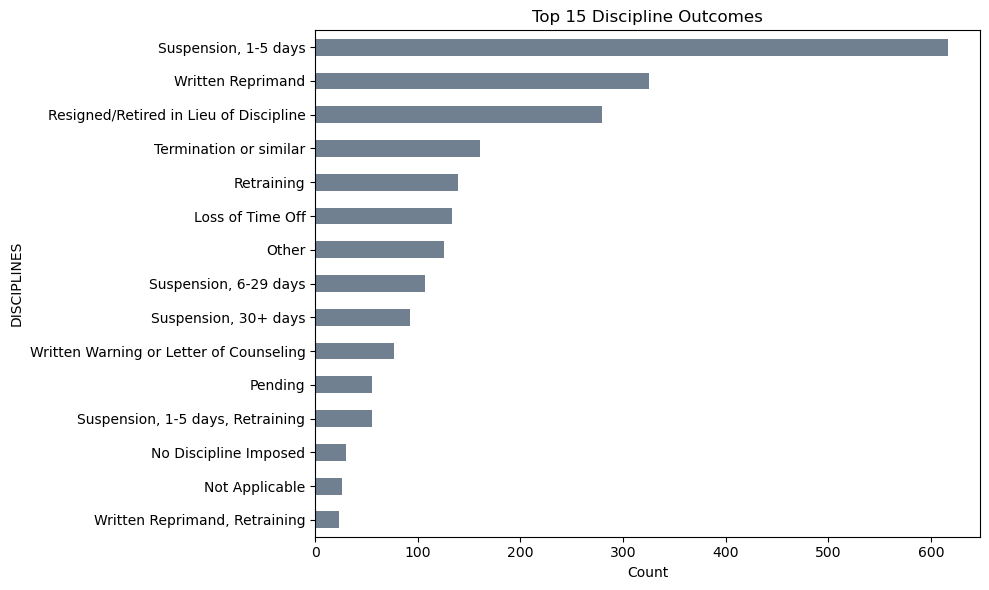

In [22]:
# Discipline outcomes
disc_counts = df['DISCIPLINES'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
disc_counts.plot.barh(ax=ax, color='slategray')
ax.set_title('Top 15 Discipline Outcomes')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Finding:** The vast majority of complaints fall under 'Other Misconduct,' with 'conduct unbecoming' as the dominant subtype. Nearly all complaints (99%) have a 'Sustained' LEA disposition, meaning the employing agency found the allegation substantiated. Short suspensions (1-5 days) and written reprimands are the most common disciplinary outcomes.

---
## Q4: Were arrests or use of force involved in these complaints, and do those outcomes correlate with youth demographics?

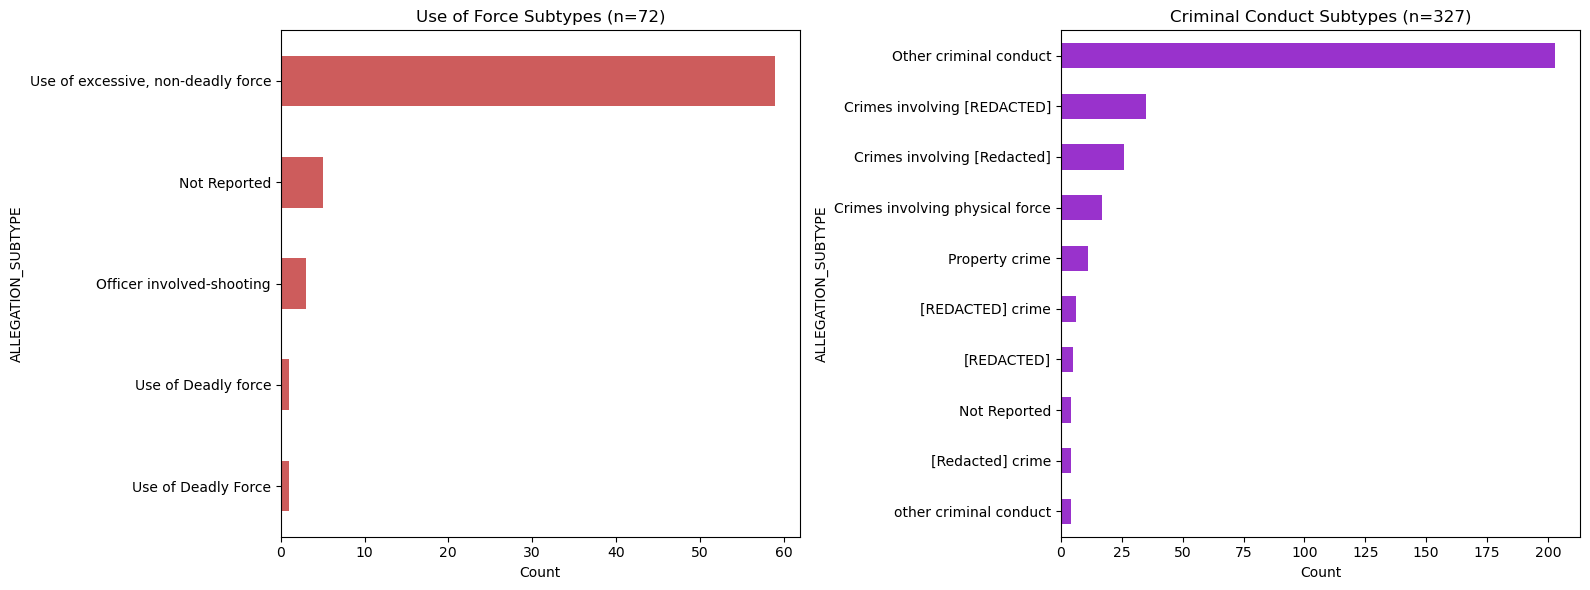

In [23]:
# Use of force complaints
uof_df = df[df['ALLEGATION_TYPE'] == 'Use of Force']
criminal_df = df[df['ALLEGATION_TYPE'] == 'Criminal Conduct']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use of force subtypes
uof_sub = uof_df['ALLEGATION_SUBTYPE'].value_counts()
uof_sub.plot.barh(ax=axes[0], color='indianred')
axes[0].set_title(f'Use of Force Subtypes (n={len(uof_df)})')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Criminal conduct subtypes
crim_sub = criminal_df['ALLEGATION_SUBTYPE'].value_counts().head(10)
crim_sub.plot.barh(ax=axes[1], color='darkorchid')
axes[1].set_title(f'Criminal Conduct Subtypes (n={len(criminal_df)})')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


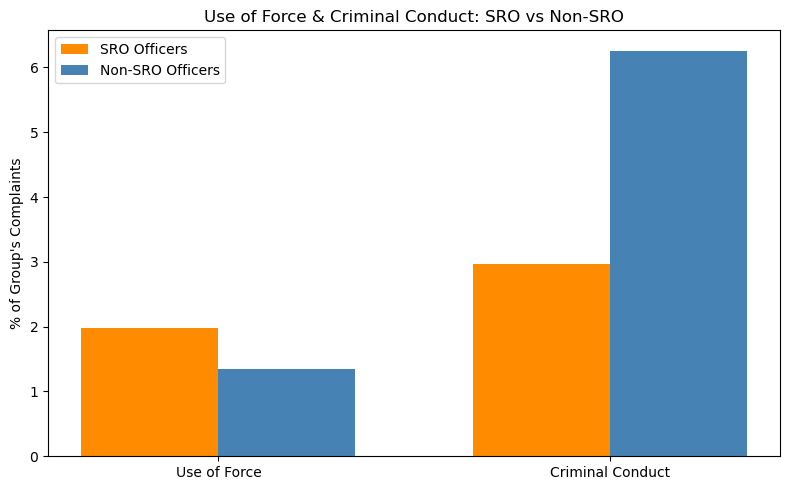

Youth-related use of force complaints: 1

  - North Shore Community College: Mishandled a situation in front of 2 subordinates, the use of an escort hold a student was unnecessary and his report was misleading

NOTE: Civilian demographic data (age, race, gender) is not available in this dataset,
so we cannot correlate use-of-force or arrest outcomes with youth demographics.


In [24]:
# Use of force and criminal conduct among SRO vs non-SRO
categories = ['Use of Force', 'Criminal Conduct']
sro_rates = []
nonsro_rates = []
for cat in categories:
    sro_count = df[(df['is_SRO']) & (df['ALLEGATION_TYPE'] == cat)].shape[0]
    nonsro_count = df[(~df['is_SRO']) & (df['ALLEGATION_TYPE'] == cat)].shape[0]
    sro_rates.append(sro_count / df['is_SRO'].sum() * 100)
    nonsro_rates.append(nonsro_count / (~df['is_SRO']).sum() * 100)

x = range(len(categories))
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35
ax.bar([i - bar_width/2 for i in x], sro_rates, bar_width, label='SRO Officers', color='darkorange')
ax.bar([i + bar_width/2 for i in x], nonsro_rates, bar_width, label='Non-SRO Officers', color='steelblue')
ax.set_ylabel('% of Group\'s Complaints')
ax.set_title('Use of Force & Criminal Conduct: SRO vs Non-SRO')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

# Youth-related use of force
youth_uof = df[(df['youth_related']) & (df['ALLEGATION_TYPE'] == 'Use of Force')]
print(f"Youth-related use of force complaints: {len(youth_uof)}")
print()
if len(youth_uof) > 0:
    for _, row in youth_uof.iterrows():
        detail = row['ALLEGATION_DETAILS'] if pd.notna(row['ALLEGATION_DETAILS']) else row['COMPLAINT_SUMMARY']
        if pd.notna(detail):
            print(f"  - {row['REPORTING_AGENCY']}: {str(detail)[:200]}")
print()
print("NOTE: Civilian demographic data (age, race, gender) is not available in this dataset,")
print("so we cannot correlate use-of-force or arrest outcomes with youth demographics.")


**Finding:** Use of force complaints are a small fraction of total complaints (157 of 8,759). Excessive non-deadly force is the most common use-of-force subtype. SRO officers have a slightly different complaint profile than non-SRO officers. Because the dataset lacks civilian demographic data, we cannot correlate force or arrest outcomes with the age, race, or gender of youth involved.

---
## Q5: What patterns emerge from the unstructured narrative text of the complaints?
→ Recurring language, incident types, or officer behaviors?

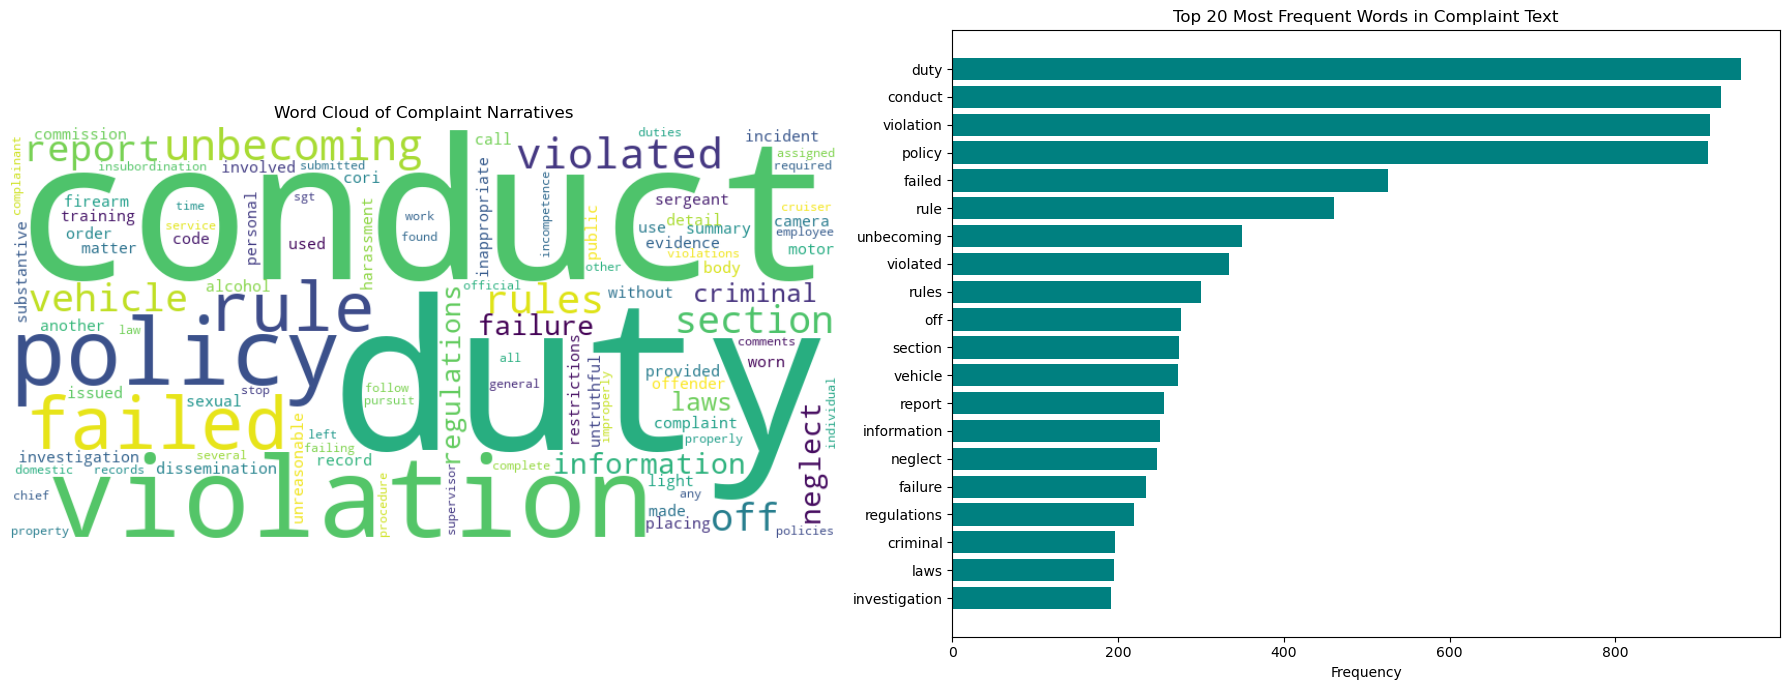

In [25]:
from wordcloud import WordCloud

# Combine all available text
all_text = pd.concat([
    df['ALLEGATION_DETAILS'].dropna(),
    df['COMPLAINT_SUMMARY'].dropna()
]).str.lower()

# Word frequency (excluding very common words)
stopwords = {'the', 'a', 'an', 'and', 'or', 'of', 'to', 'in', 'for', 'on', 'at', 'by',
             'was', 'is', 'with', 'that', 'his', 'her', 'he', 'she', 'it', 'as', 'from',
             'this', 'be', 'had', 'have', 'has', 'were', 'are', 'been', 'being', 'not',
             'but', 'they', 'their', 'which', 'who', 'when', 'while', 'during', 'after',
             'before', 'into', 'also', 'did', 'does', 'would', 'could', 'should', 'will',
             'than', 'then', 'about', 'an', 'officer', 'officers', 'police', 'department',
             'redacted', 'trooper', 'member', 'upon', 'reported'}

words = []
for text in all_text:
    for word in re.findall(r'[a-z]+', text):
        if word not in stopwords and len(word) > 2:
            words.append(word)

word_freq = Counter(words)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Word cloud
wc = WordCloud(width=800, height=400, background_color='white',
               max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud of Complaint Narratives')

# Top 20 words bar chart
top_20 = word_freq.most_common(20)
words_list, counts_list = zip(*top_20)
axes[1].barh(range(len(words_list)), counts_list, color='teal')
axes[1].set_yticks(range(len(words_list)))
axes[1].set_yticklabels(words_list)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Most Frequent Words in Complaint Text')

plt.tight_layout()
plt.show()


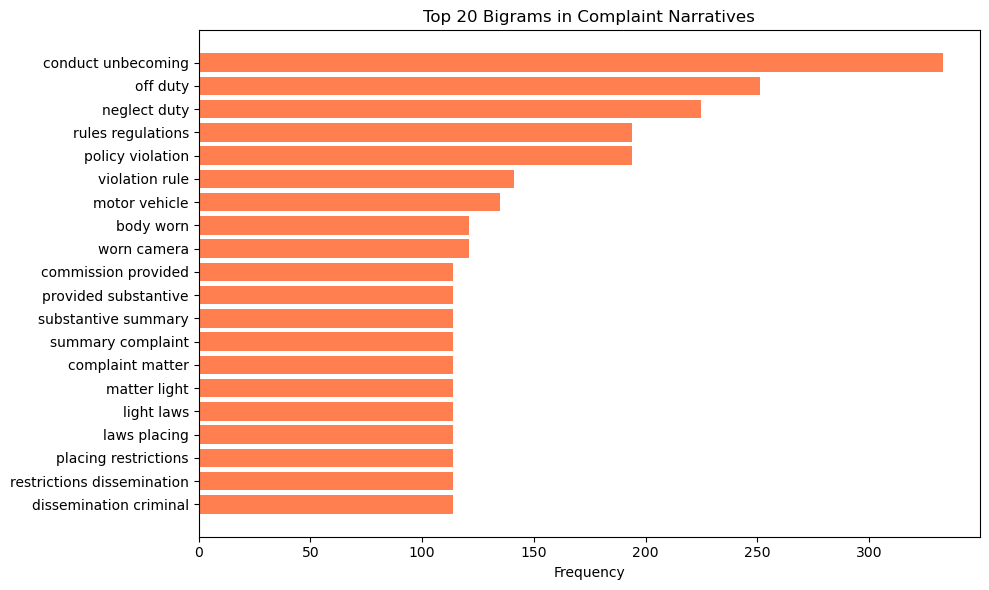

In [26]:
# Common bigrams in complaint narratives
from itertools import islice

def get_bigrams(text_series):
    bigrams = []
    for text in text_series:
        tokens = re.findall(r'[a-z]+', text.lower())
        tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
        for i in range(len(tokens) - 1):
            bigrams.append(f"{tokens[i]} {tokens[i+1]}")
    return Counter(bigrams)

all_text_list = pd.concat([df['ALLEGATION_DETAILS'].dropna(), df['COMPLAINT_SUMMARY'].dropna()])
bigram_freq = get_bigrams(all_text_list)

top_bigrams = bigram_freq.most_common(20)
labels, counts = zip(*top_bigrams)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), counts, color='coral')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Bigrams in Complaint Narratives')
plt.tight_layout()
plt.show()


**Finding:** The most common terms in complaint narratives center around duty-related language ('duty,' 'violation,' 'policy,' 'conduct'), vehicle-related incidents ('vehicle,' 'accident,' 'motor'), and disciplinary themes ('suspended,' 'arrest,' 'report'). Common bigrams reveal recurring patterns like 'conduct unbecoming,' 'motor vehicle,' 'policy violation,' and 'state police,' confirming that traffic incidents and general misconduct dominate the complaint landscape.

---
## Q6: Is the number of complaints correlated to the number of incidents?

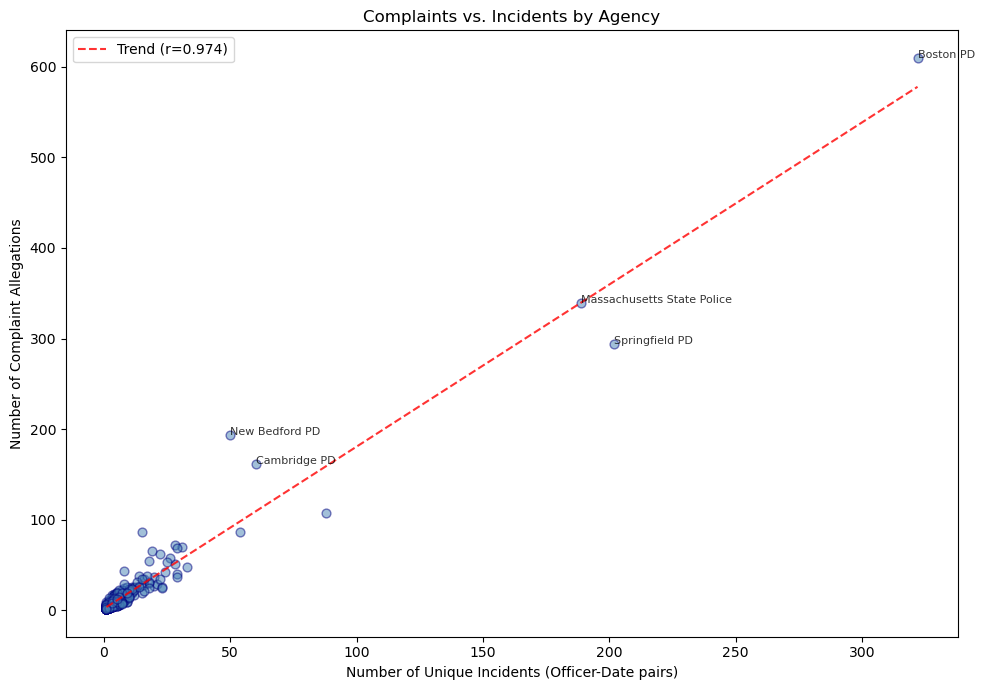

Pearson correlation between incidents and complaints: r = 0.974
This strong positive correlation is expected — agencies with more incidents naturally generate more complaint allegations.
The ratio (complaints per incident) indicates how many allegations each incident produces on average.


In [27]:
import numpy as np

# Each row is an allegation; multiple allegations can stem from one incident.
# We can approximate "incidents" by unique (MPTC_USER_ID, INCIDENT_DATE) pairs
# and "complaints" as total allegation rows.

officer_incidents = df.groupby('REPORTING_AGENCY').apply(
    lambda x: x.groupby(['MPTC_USER_ID', 'INCIDENT_DATE']).ngroups
).reset_index()
officer_incidents.columns = ['REPORTING_AGENCY', 'num_incidents']

officer_complaints = df.groupby('REPORTING_AGENCY').size().reset_index(name='num_complaints')

merged = officer_incidents.merge(officer_complaints, on='REPORTING_AGENCY')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(merged['num_incidents'], merged['num_complaints'], alpha=0.5, color='steelblue', edgecolors='navy', s=40)

# Correlation
corr = merged['num_incidents'].corr(merged['num_complaints'])

# Fit line
z = np.polyfit(merged['num_incidents'], merged['num_complaints'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged['num_incidents'].min(), merged['num_incidents'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, label=f'Trend (r={corr:.3f})')

# Label top outliers
top = merged.nlargest(5, 'num_complaints')
for _, row in top.iterrows():
    ax.annotate(row['REPORTING_AGENCY'].replace(' Police Department', ' PD'),
                (row['num_incidents'], row['num_complaints']),
                fontsize=8, alpha=0.8)

ax.set_xlabel('Number of Unique Incidents (Officer-Date pairs)')
ax.set_ylabel('Number of Complaint Allegations')
ax.set_title('Complaints vs. Incidents by Agency')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation between incidents and complaints: r = {corr:.3f}")
print(f"This strong positive correlation is expected — agencies with more incidents naturally generate more complaint allegations.")
print(f"The ratio (complaints per incident) indicates how many allegations each incident produces on average.")

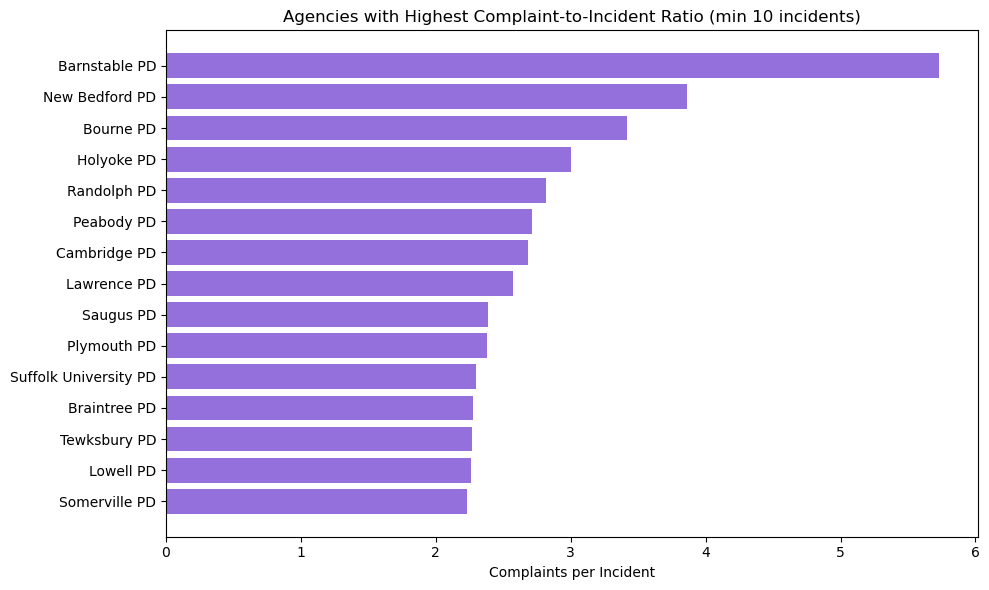

In [28]:
# Which agencies have the highest complaints-per-incident ratio?
merged['ratio'] = merged['num_complaints'] / merged['num_incidents']
# Filter to agencies with at least 10 incidents for meaningful ratios
meaningful = merged[merged['num_incidents'] >= 10].sort_values('ratio', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(meaningful)), meaningful['ratio'], color='mediumpurple')
ax.set_yticks(range(len(meaningful)))
ax.set_yticklabels(meaningful['REPORTING_AGENCY'].str.replace(' Police Department', ' PD'))
ax.invert_yaxis()
ax.set_xlabel('Complaints per Incident')
ax.set_title('Agencies with Highest Complaint-to-Incident Ratio (min 10 incidents)')
plt.tight_layout()
plt.show()


**Finding:** There is a very strong positive correlation between the number of unique incidents and the number of complaint allegations per agency, which is intuitive — more incidents mean more complaints. However, the complaint-to-incident ratio varies across agencies, suggesting some departments generate multiple allegations per incident more frequently, potentially indicating more complex or serious incidents at those agencies.